<a href="https://colab.research.google.com/github/shivani5015/Machine-learning-Roadmap/blob/main/ML_MODEL_WORKING_STEPS_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("/content/covid_toy.csv")

print(df.head())

   age  gender  fever cough     city has_covid
0   60    Male  103.0  Mild  Kolkata        No
1   27    Male  100.0  Mild    Delhi       Yes
2   42    Male  101.0  Mild    Delhi        No
3   31  Female   98.0  Mild  Kolkata        No
4   65  Female  101.0  Mild   Mumbai        No


In [ ]:
# Step 3: Check Missing Values
# Before applying any model, check missing values.

In [ ]:
print(df.isnull().sum())

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64


In [ ]:
# Step 4: Handle Missing Values

In [ ]:
imputer = SimpleImputer(strategy='median')
df['fever'] = imputer.fit_transform(df[['fever']])

In [ ]:
# Step 5: Visualize Target Variable
# Check whether classes are balanced.

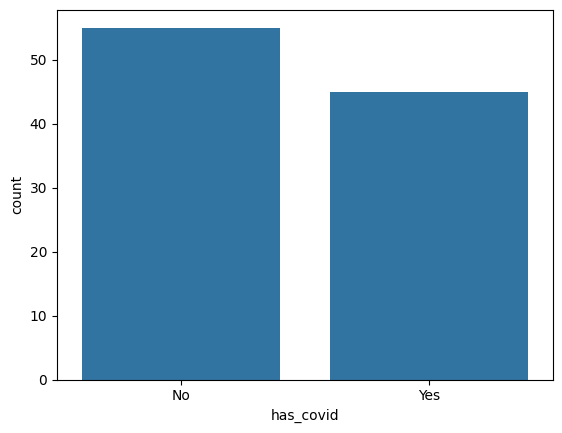

In [ ]:
sns.countplot(
    x='has_covid',
    data=df
)
plt.show()

In [ ]:
# Step 6: Visualize Numerical Features
# Look at the relationship between Age and Fever.

In [ ]:
fig = px.scatter(
    df,
    x='age',
    y='fever',
    color='has_covid',
    title='Age vs Fever'
)

fig.show()

In [ ]:
# Linear Case
# YES YES YES
# -----------------
# NO NO NO
# Straight line can separate the classes.

# Non-linear Case
# YES NO YES
# NO YES NO
# YES NO YES

# Classes overlap.

In [ ]:
# Step 7: Pairplot
# Observe relationships among features

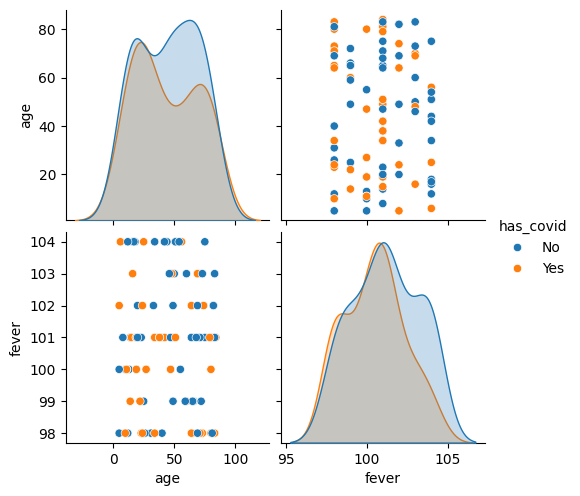

In [ ]:
sns.pairplot(
    df,
    hue='has_covid'
)
plt.show()

In [ ]:
# Interpretation

# Clear separation
# ↓
# Linear
# Heavy overlap

# ↓
# Non-linear

In [ ]:
# Step 8: Separate Features and Target

In [ ]:
X = df.drop('has_covid', axis=1)
y = df['has_covid']

In [ ]:
# Step 9: Encoding

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
# Step 10: Feature Scaling
# Scaling is required for:
# Logistic Regression
# KNN
# SVM

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 11: PCA Visualization
# Reduce dimensions to 2 and visualize.

In [ ]:
pca = PCA(
    n_components=2
)
X_pca = pca.fit_transform(
    X_scaled
)

In [ ]:
# Create dataframe:

In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)
pca_df['target'] = y

In [ ]:
# Visualize:

In [ ]:
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='target',
    title='PCA Visualization'
)
fig.show()

In [ ]:
# Interpretation
# If clusters are separated
# OOOOOOOO
# -----------
# XXXXXXXX

# Data is approximately linear.
# Suitable Models:
# Logistic Regression
# Linear SVM


# If clusters overlap:
# OXOXOXOX

# XOXOXOXO

# Data is non-linear.

# Suitable Models:
# KNN
# Decision Tree
# SVM(RBF)

In [ ]:
# Step 12: Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Step 13: Baseline Model
# Logistic Regression
# Always start with the simplest model.

In [ ]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:",acc_lr)

Accuracy: 0.45


In [ ]:
# Step 14: Linear SVM
# Check whether data is linearly separable.

In [ ]:
svm_linear = SVC(
    kernel='linear'
)

svm_linear.fit(
    X_train,
    y_train
)

y_pred_linear = svm_linear.predict(
    X_test
)

acc_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print(acc_linear)

0.4


In [ ]:
# Step 15: KNN
# Useful for non-linear relationships.

In [ ]:
knn = KNeighborsClassifier()

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

acc_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print(acc_knn)

0.5


In [ ]:
# Step 16: Decision Tree
# Captures complex rules.

In [ ]:
dt = DecisionTreeClassifier()

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)

acc_dt = accuracy_score(
    y_test,
    y_pred_dt
)
print(acc_dt)

0.45


In [ ]:
# Step 17: SVM with RBF Kernel
# Best for complex non-linear boundaries.

In [ ]:
svm_rbf = SVC(
    kernel='rbf'
)

svm_rbf.fit(
    X_train,
    y_train
)

y_pred_rbf = svm_rbf.predict(
    X_test
)

acc_rbf = accuracy_score(
    y_test,
    y_pred_rbf
)

print(acc_rbf)

0.4


In [ ]:
# Step 18: Compare All Models

In [ ]:
results = pd.DataFrame({

'Model':
[
'Logistic Regression',
'Linear SVM',
'KNN',
'Decision Tree',
'SVM RBF'
],

'Accuracy':
[
acc_lr,
acc_linear,
acc_knn,
acc_dt,
acc_rbf
]

})

print(
results.sort_values(
    by='Accuracy',
    ascending=False
)
)

                 Model  Accuracy
2                  KNN      0.50
0  Logistic Regression      0.45
3        Decision Tree      0.45
1           Linear SVM      0.40
4              SVM RBF      0.40


In [ ]:
# So , KNN will be best moodel because our data is not linear .

In [ ]:
# Now If I want to check all models in a loop then i can use this method .

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import (
    GaussianNB,
    BernoulliNB
)

In [ ]:
# models = {

#     "Logistic Regression":
#     LogisticRegression(),

#     "Linear SVM":
#     SVC(kernel='linear'),

#     "KNN":
#     KNeighborsClassifier(),

#     "Decision Tree":
#     DecisionTreeClassifier(),

#     "SVM RBF":
#     SVC(kernel='rbf')

# }


models = {

    "Logistic Regression":
    LogisticRegression(),

    "Linear SVM":
    SVC(kernel='linear'),

    "SVM RBF":
    SVC(kernel='rbf'),

    "KNN":
    KNeighborsClassifier(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Gaussian Naive Bayes":
    GaussianNB(),


    "Bernoulli Naive Bayes":
    BernoulliNB()

}

In [ ]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store result
    results.append([name, acc])

    print(f"{name} Accuracy = {acc:.4f}")

Logistic Regression Accuracy = 0.4500
Linear SVM Accuracy = 0.4000
SVM RBF Accuracy = 0.4000
KNN Accuracy = 0.5000
Decision Tree Accuracy = 0.4000
Gaussian Naive Bayes Accuracy = 0.4000
Bernoulli Naive Bayes Accuracy = 0.4000


In [ ]:
result_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)
print(result_df)

                   Model  Accuracy
0    Logistic Regression      0.45
1             Linear SVM      0.40
2                SVM RBF      0.40
3                    KNN      0.50
4          Decision Tree      0.40
5   Gaussian Naive Bayes      0.40
6  Bernoulli Naive Bayes      0.40


In [ ]:
# Sort Models

In [ ]:
result_df = result_df.sort_values(
    by='Accuracy',
    ascending=False
)
print(result_df)

                   Model  Accuracy
3                    KNN      0.50
0    Logistic Regression      0.45
1             Linear SVM      0.40
2                SVM RBF      0.40
4          Decision Tree      0.40
5   Gaussian Naive Bayes      0.40
6  Bernoulli Naive Bayes      0.40


In [ ]:
# How we can check which column is relvant or irrelevant .

In [ ]:
# Dataset
#    ↓
# Identify Target Column
#    ↓
# Numerical Columns
#    ↓
# Correlation Matrix
#    ↓
# Heatmap
#    ↓
# Check Relationship Strength
#    ↓
# Strong Correlation → Keep
# Weak Correlation → Consider Removing
# Very High Correlation Between Features (>0.9)
# ↓
# Drop One Feature
# ↓
# Train Model

In [ ]:
print(df.dtypes)

age            int64
gender        object
fever        float64
cough         object
city          object
has_covid     object
dtype: object


In [ ]:
num_cols = ['age', 'fever']

In [ ]:
corr = df[num_cols].corr()
print(corr)

            age     fever
age    1.000000 -0.013316
fever -0.013316  1.000000


In [ ]:
# Correlation Interpretation

In [ ]:
# | Correlation Value | Meaning               |
# | ----------------- | --------------------- |
# | 0 to 0.3          | Weak Relationship     |
# | 0.3 to 0.7        | Moderate Relationship |
# | 0.7 to 1          | Strong Relationship   |
# | Near 0            | No Relationship       |
# | Negative          | Inverse Relationship  |
